# Relational Graph Transformer on the Causal Elliptic++ Graph

A heterogeneous **HGT-based relational graph transformer** under strict
per-target inductive causality. For every prediction at timestep `k`, the
model sees only graph state with `t' ≤ k` -- training, validation, and test.

## Why a relational graph transformer

Multi-head attention with per-edge-type Q/K/V projections (HGTConv) gives:
- Attention-weighted neighbour aggregation that adapts per relation
- Type-specific transforms (separate semantics for `wallet→tx` vs `tx→wallet`
  vs `wallet→wallet` vs `tx→tx`)
- Edge-type embeddings baked into attention scores

Combined with strict per-target snapshots, the result is a deployment-faithful
inductive temporal-graph model in the spirit of TGN/TGAT but using a static
relational-transformer block per snapshot.

## Causality contract — strict per-target everywhere

For target tx τ at time `t = k`, the model is forward-passed on the **per-target
snapshot** `g_k = build_snapshot(k)`:
- All edges have `edge_t ≤ k`
- Wallet features are causal cumulative through `k`
- Tx features include 103 phase1 trajectory features (strict `searchsorted(side="left")`)
- Tx features include 5 PPR features (seed = illicit txs at `τ < k`, strict)

Because every node/edge in `g_k` has `t' ≤ k`, **the snapshot construction itself
is the time-respecting attention mask** -- HGTConv attends only over the
sampled subgraph drawn from `g_k`, so by construction τ-at-k cannot attend to
future-of-k information. Equivalent to attention with edge-time masks but
much more efficient.

## Tx node features (290 = 182 + 103 + 5)

1. **Raw 182**: from `txs_features.csv` (per-tx, time-independent)
2. **Trajectory 103** (phase1): label propagation, second-hop illicit
   exposure, structural profile, temporal patterns, cross-side composites.
   All computed with strict `τ < t_target`.
3. **PPR 5** (Block C from `step4_richer_features`): personalized PageRank
   on the cumulative bipartite graph, seeded from illicit txs with `τ < t`.
   Captures multi-hop reachability from the illicit subgraph that pure
   1-hop trajectory features can't express.

## Wallet node features (55)

Causal cumulative wallet features through `k` from `wallets_features_causal.csv`.

## Edges (full causal graph)

- **bipartite** `wallet ↔ tx`: included iff host tx `t_tx ≤ k`
- **wallet ↔ wallet** (AddrAddr): included iff `first_t(e) ≤ k`
- **tx ↔ tx** (within-step): included iff `t_edge ≤ k`

## Anti-overfitting (RGT is expressive — ~1M params)

- `HIDDEN = 128`, `HEADS = 4` (32 per head)
- `N_LAYERS = 2` (transformers over-smooth past 2-3 hetero layers)
- `DROPOUT = 0.4`
- `ATTN_DROPOUT = 0.4`
- `WEIGHT_DECAY = 5e-4`
- `LR = 5e-4` with `GRAD_CLIP = 1.0` for noisy per-timestep updates
- Pre-LN style (LN before attention/FFN, residual after) — standard for
  stable transformer training; avoids cross-batch normalization.

In [ ]:
!pip install -q \
  "numpy<2" \
  "torch-geometric>=2.4.0" \
  "scikit-learn>=1.3.0" \
  "pandas>=2.0.0" \
  "matplotlib>=3.7.0" \
  "seaborn>=0.12.0" \
  "pyyaml>=6.0" \
  "tqdm>=4.65.0"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 104.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 77.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatib

In [ ]:
!pip install -q --force-reinstall \
  "numpy<2" \
  "pandas>=2.0,<2.2.3" \
  "scikit-learn>=1.3.0" \
  "torch-geometric>=2.4.0"

import os
os.kill(os.getpid(), 9)


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 8.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.6/79.6 kB 11.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 185.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 182.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 kB 37.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 22.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 34.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.1/510.1 kB 59.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 89.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import torch
TORCH = ".".join(torch.__version__.split("+")[0].split(".")[:2]) + ".0"   # e.g. '2.5.0'
CUDA  = f"cu{torch.version.cuda.replace('.', '')}" if torch.version.cuda else "cpu"
print(f"installing pyg extensions for torch={TORCH} cuda={CUDA}")
!pip install -q pyg-lib torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-{TORCH}+{CUDA}.html

import os
os.kill(os.getpid(), 9)

installing pyg extensions for torch=2.10.0 cuda=cu128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 55.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 181.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 111.9 MB/s eta 0:00:00


In [ ]:
# Cell 1: imports, paths, config

import os, sys, time, json, math, copy, gc
from collections import defaultdict
from contextlib import nullcontext

import numpy as np
import pandas as pd
import scipy.sparse as sp
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score, precision_recall_curve
from torch_geometric.data import HeteroData
from torch_geometric.nn import HGTConv
from torch_geometric.loader import NeighborLoader

# --- Path resolution: works on Colab (drive mount) and local ---
COLAB = False
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    COLAB = True
    REPO = "/content/drive/MyDrive/stat175-final-project"
    ACTORS = os.path.join(REPO, "actor_data")
    TX = os.path.join(REPO, "data")
except Exception:
    REPO = os.path.abspath(os.path.join(os.getcwd(), "..", "..", ".."))
    if not os.path.exists(os.path.join(REPO, "actors_data")):
        REPO = "/Users/jarayliu/Documents/GitHub/stat175-final"
    ACTORS = os.path.join(REPO, "actors_data")
    TX = os.path.join(REPO, "transactions_data")
print("repo:", REPO, " colab:", COLAB)

# --- Reproducibility ---
RANDOM_SEED = 175
np.random.seed(RANDOM_SEED); torch.manual_seed(RANDOM_SEED)

# --- Time-window protocol ---
N_TIMESTEPS = 49
TRAIN_END = 29
VAL_END = 34
TEST_START = 35
TEST_TIMESTEPS = list(range(TEST_START, N_TIMESTEPS + 1))
WALK_VAL_WIN = 4

# --- Model + training config (sized for ~26K train labels with 290-dim tx + 55-dim wallet) ---
HIDDEN = 96                 # down from 128 -- ~600K total params, better matched to label count
N_LAYERS = 2                # 2 RGT blocks (3+ over-smooths in hetero attention)
HEADS = 3                  # down from 4 -- 48-dim per head, halves HGT Q/K/V param count
DROPOUT = 0.4
ATTN_DROPOUT = 0.4
LR = 1e-4                   # down from 5e-4 -- conservative for transformer + per-timestep noise
WEIGHT_DECAY = 5e-4
GRAD_CLIP = 1.0
N_EPOCHS_STRICT = 50
N_EPOCHS_WALK = 15          # up from 10 -- RGT needs more steps to converge from scratch each step
PATIENCE = 10

# --- NeighborLoader sampling (tighter -- smaller subgraphs, less variance per step) ---
SAMPLE_FANOUT = [30, 25]     # down from [15, 10]; one entry per layer; matches N_LAYERS
SAMPLE_BATCH  = 2048

# --- bf16 mixed precision (A100 Tensor Cores) ---
USE_BF16 = True

# --- Personalized PageRank config ---
PPR_DAMP = 0.85
PPR_ITERATIONS = 30

# --- Device ---
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
print("device:", DEVICE, " bf16:", USE_BF16 and DEVICE.type == "cuda")


def free_cuda():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def amp_ctx():
    if USE_BF16 and DEVICE.type == "cuda":
        return torch.amp.autocast(device_type="cuda", dtype=torch.bfloat16)
    return nullcontext()


Mounted at /content/drive
repo: /content/drive/MyDrive/stat175-final-project  colab: True
device: cuda  bf16: True


In [ ]:
# Cell 2: load all data

t0 = time.time()

tx_feat_df = pd.read_csv(os.path.join(TX, "txs_features.csv"))
tx_id_arr = tx_feat_df["txId"].values
tx_t_arr  = tx_feat_df["Time step"].values.astype(np.int64)
TX_FEAT_COLS = [c for c in tx_feat_df.columns if c not in ("txId", "Time step")]
tx_X_raw = tx_feat_df[TX_FEAT_COLS].fillna(0.0).values.astype(np.float32)
N_TX = len(tx_id_arr)
F_TX = tx_X_raw.shape[1]
print(f"tx: N={N_TX:,}  F_TX={F_TX}  t-range=[{tx_t_arr.min()}, {tx_t_arr.max()}]")

tx_cls_df = pd.read_csv(os.path.join(TX, "txs_classes.csv"))
cls_map = dict(zip(tx_cls_df["txId"].values, tx_cls_df["class"].values.astype(np.int64)))
tx_label = np.full(N_TX, -1, dtype=np.int64)
for i, txid in enumerate(tx_id_arr):
    c = cls_map.get(txid)
    if c == 1:   tx_label[i] = 1
    elif c == 2: tx_label[i] = 0
print(f"tx labels: illicit={(tx_label==1).sum():,}  licit={(tx_label==0).sum():,}  unknown={(tx_label==-1).sum():,}")

# --- Causal wallet features (locate file robustly) ---
def _find_csv(candidates):
    for p in candidates:
        if os.path.exists(p): return p
    return None

wf_path = _find_csv([
    os.path.join(ACTORS, "wallets_features_causal.csv"),
    os.path.join(ACTORS, "wallets_features_causal.txt"),
])
assert wf_path is not None, f"could not find wallets_features_causal in {ACTORS}"
wf = pd.read_csv(wf_path)
WF_FEAT_COLS = [c for c in wf.columns if c not in ("address", "Time step")]
F_W = len(WF_FEAT_COLS)
print(f"wallet causal feats: {len(wf):,} rows, F_W={F_W}")

# --- Bipartite ---
ai = pd.read_csv(os.path.join(ACTORS, "AddrTx_edgelist.txt"))
ao = pd.read_csv(os.path.join(ACTORS, "TxAddr_edgelist.txt"))
print(f"bipartite: in={len(ai):,}  out={len(ao):,}")

# --- AddrAddr causal ---
aa_path = _find_csv([
    os.path.join(ACTORS, "AddrAddr_edgelist_causal.csv"),
    os.path.join(ACTORS, "AddrAddr_edgelist_causal.txt"),
])
assert aa_path is not None, f"could not find AddrAddr_edgelist_causal in {ACTORS}"
aa = pd.read_csv(aa_path)
print(f"wallet-wallet edges: {len(aa):,}  first_t range=[{int(aa['first_t'].min())}, {int(aa['first_t'].max())}]")

# --- tx-tx ---
tt = pd.read_csv(os.path.join(TX, "txs_edgelist.csv"))
print(f"tx-tx edges: {len(tt):,}")

print(f"[load] {time.time()-t0:.1f}s")


tx: N=203,769  F_TX=182  t-range=[1, 49]
tx labels: illicit=4,545  licit=42,019  unknown=157,205
wallet causal feats: 1,268,260 rows, F_W=55
bipartite: in=477,117  out=837,124
wallet-wallet edges: 2,868,964  first_t range=[1, 49]
tx-tx edges: 234,355
[load] 13.0s


In [ ]:
# Cell 3: node ID maps + per-edge timestamp arrays

t0 = time.time()

tx_to_idx = {txid: i for i, txid in enumerate(tx_id_arr)}
wallet_addrs = wf["address"].drop_duplicates().values
N_W = len(wallet_addrs)
w_to_idx = {a: i for i, a in enumerate(wallet_addrs)}
print(f"N_TX={N_TX:,}  N_W={N_W:,}")

ai_w = np.array([w_to_idx[w] for w in ai["input_address"].values], dtype=np.int64)
ai_x = np.array([tx_to_idx[t] for t in ai["txId"].values], dtype=np.int64)
ai_t = tx_t_arr[ai_x]

ao_x = np.array([tx_to_idx[t] for t in ao["txId"].values], dtype=np.int64)
ao_w = np.array([w_to_idx[w] for w in ao["output_address"].values], dtype=np.int64)
ao_t = tx_t_arr[ao_x]

aa_in  = np.array([w_to_idx[w] for w in aa["input_address"].values],  dtype=np.int64)
aa_out = np.array([w_to_idx[w] for w in aa["output_address"].values], dtype=np.int64)
aa_t   = aa["first_t"].values.astype(np.int64)

tt_a = np.array([tx_to_idx[t] for t in tt["txId1"].values], dtype=np.int64)
tt_b = np.array([tx_to_idx[t] for t in tt["txId2"].values], dtype=np.int64)
tt_t = tx_t_arr[tt_a]
assert (tx_t_arr[tt_a] == tx_t_arr[tt_b]).all(), "tx-tx edges should be within-timestep"

print(f"  bipartite: in={len(ai_w):,}  out={len(ao_x):,}  walletXwallet={len(aa_in):,}  txXtx={len(tt_a):,}")
print(f"[node/edge build] {time.time()-t0:.1f}s")


N_TX=203,769  N_W=822,942
  bipartite: in=477,117  out=837,124  walletXwallet=2,868,964  txXtx=234,355
[node/edge build] 1.7s


In [ ]:
# Cell 4: wallet feature lookup table

t0 = time.time()

wf_sorted = wf.sort_values(["address", "Time step"]).reset_index(drop=True)
addr_arr = wf_sorted["address"].values
t_arr_wf = wf_sorted["Time step"].values.astype(np.int64)
WF_RAW = wf_sorted[WF_FEAT_COLS].fillna(0.0).values.astype(np.float32)

last_row_at_T = np.full((N_TIMESTEPS + 1, N_W), -1, dtype=np.int32)
addr_to_id = np.array([w_to_idx[a] for a in wf_sorted["address"].values], dtype=np.int64)
for j in range(len(wf_sorted)):
    last_row_at_T[t_arr_wf[j], addr_to_id[j]] = j
for T in range(1, N_TIMESTEPS + 1):
    mask = (last_row_at_T[T] == -1)
    last_row_at_T[T, mask] = last_row_at_T[T - 1, mask]
print(f"  last_row_at_T: shape={last_row_at_T.shape} ({last_row_at_T.nbytes/1024/1024:.0f} MB)")


def wallet_features_at_T(T_query: int) -> np.ndarray:
    idx = last_row_at_T[T_query]
    out = np.zeros((N_W, F_W), dtype=np.float32)
    mask = idx >= 0
    out[mask] = WF_RAW[idx[mask]]
    return out

print(f"[wallet feature lookup] {time.time()-t0:.1f}s")


  last_row_at_T: shape=(50, 822942) (157 MB)
[wallet feature lookup] 3.4s


In [ ]:
# Cell 4b: trajectory features (port from phase1_trajectory_signal.ipynb)
#
# 103 features per tx, computed using STRICT tau < t priors via
# np.searchsorted(side="left").

t0 = time.time()
print("Building chronological structures for trajectory features...")

incident_in  = defaultdict(list)
incident_out = defaultdict(list)
for w_idx, tx_idx in zip(ai_w, ai_x):
    incident_in[int(tx_idx)].append(int(w_idx))
for tx_idx, w_idx in zip(ao_x, ao_w):
    incident_out[int(tx_idx)].append(int(w_idx))

seen = set()
pairs = []
for w_idx, tx_idx in zip(ai_w, ai_x):
    key = (int(w_idx), int(tx_idx))
    if key in seen: continue
    seen.add(key)
    pairs.append((int(w_idx), int(tx_idx), int(tx_t_arr[tx_idx]), int(tx_label[tx_idx])))
for tx_idx, w_idx in zip(ao_x, ao_w):
    key = (int(w_idx), int(tx_idx))
    if key in seen: continue
    seen.add(key)
    pairs.append((int(w_idx), int(tx_idx), int(tx_t_arr[tx_idx]), int(tx_label[tx_idx])))
del seen
pairs.sort(key=lambda r: (r[0], r[2]))

wallet_t_traj   = {}
wallet_tx_traj  = {}
wallet_lab_traj = {}
prev_w = -1
buf_t, buf_tx, buf_lab = [], [], []
for w, tx, t, lab in pairs:
    if w != prev_w:
        if prev_w >= 0:
            wallet_t_traj[prev_w]   = np.array(buf_t,   dtype=np.int64)
            wallet_tx_traj[prev_w]  = np.array(buf_tx,  dtype=np.int64)
            wallet_lab_traj[prev_w] = np.array(buf_lab, dtype=np.int64)
        prev_w = w
        buf_t, buf_tx, buf_lab = [], [], []
    buf_t.append(t); buf_tx.append(tx); buf_lab.append(lab)
if prev_w >= 0:
    wallet_t_traj[prev_w]   = np.array(buf_t,   dtype=np.int64)
    wallet_tx_traj[prev_w]  = np.array(buf_tx,  dtype=np.int64)
    wallet_lab_traj[prev_w] = np.array(buf_lab, dtype=np.int64)
del pairs

wallet_event_count = {w: len(arr) for w, arr in wallet_t_traj.items()}
wallet_has_illicit_by = {}
for w, labs in wallet_lab_traj.items():
    illicit_mask = (labs == 1)
    if illicit_mask.any():
        wallet_has_illicit_by[w] = int(wallet_t_traj[w][illicit_mask].min())

print(f"  wallets with timelines: {len(wallet_t_traj):,}  illicit history: {len(wallet_has_illicit_by):,}")

agg_feat_names = ["total_BTC", "fees", "num_input_addresses", "num_output_addresses"]
agg_feat_idxs  = [TX_FEAT_COLS.index(c) for c in agg_feat_names]
total_btc_idx  = TX_FEAT_COLS.index("total_BTC")
F_AGG = len(agg_feat_names)

MAX_INCIDENT_PER_SIDE = 32
MAX_CO_WALLETS        = 150
RECENCY_SENTINEL      = N_TIMESTEPS * 2
DECAY_RATE            = 0.2


def pick_top_wallets(wlist, k=MAX_INCIDENT_PER_SIDE):
    if len(wlist) <= k: return list(wlist)
    cnts = np.array([wallet_event_count.get(w, 0) for w in wlist], dtype=np.int64)
    order = np.argsort(-cnts, kind="stable")
    return [wlist[i] for i in order[:k]]


def per_wallet_priors(w, t_query):
    tarr = wallet_t_traj.get(w)
    if tarr is None: return None
    cut = int(np.searchsorted(tarr, t_query, side="left"))   # STRICT tau < t_query
    if cut == 0: return None
    prior_t   = tarr[:cut]
    prior_lab = wallet_lab_traj[w][:cut]
    prior_tx  = wallet_tx_traj[w][:cut]
    illicit_mask = (prior_lab == 1); licit_mask = (prior_lab == 0)
    n_illicit = int(illicit_mask.sum()); n_licit = int(licit_mask.sum())
    n_labelled = n_illicit + n_licit
    last_illicit_t = int(prior_t[illicit_mask].max()) if n_illicit > 0 else -1
    if n_illicit > 0:
        decay_w = np.exp(-DECAY_RATE * (t_query - prior_t[illicit_mask]).astype(np.float64))
        decayed_illicit_score = float(decay_w.sum())
    else:
        decayed_illicit_score = 0.0
    illicit_frac = n_illicit / max(n_labelled, 1)
    co_wallets = set()
    for tx_i in prior_tx:
        tx_i_int = int(tx_i)
        for cw in incident_in.get(tx_i_int, []):
            if cw != w: co_wallets.add(cw)
        for cw in incident_out.get(tx_i_int, []):
            if cw != w: co_wallets.add(cw)
        if len(co_wallets) >= MAX_CO_WALLETS: break
    n_co_wallets = len(co_wallets)
    n_co_illicit = sum(1 for cw in co_wallets
                      if wallet_has_illicit_by.get(cw) is not None
                      and wallet_has_illicit_by[cw] < t_query)
    unique_in_partners, unique_out_partners = set(), set()
    for tx_i in prior_tx:
        tx_i_int = int(tx_i)
        for cw in incident_in.get(tx_i_int, []):
            if cw != w: unique_in_partners.add(cw)
        for cw in incident_out.get(tx_i_int, []):
            if cw != w: unique_out_partners.add(cw)
    n_in_partners  = len(unique_in_partners)
    n_out_partners = len(unique_out_partners)
    fan_asymmetry  = n_out_partners / max(n_in_partners, 1)
    n_prior = int(cut)
    age     = int(t_query - prior_t[0])
    recency = int(t_query - prior_t[-1])
    n_recent_5 = int(((t_query - prior_t) <= 5).sum())
    n_recent_1 = int(((t_query - prior_t) <= 1).sum())
    if n_prior >= 2:
        iat = np.diff(prior_t.astype(np.float64))
        iat_mean = float(iat.mean()); iat_std = float(iat.std())
        burstiness = float((iat_std - iat_mean) / (iat_std + iat_mean + 1e-8))
    else:
        iat_mean = iat_std = 0.0; burstiness = 0.0
    velocity = n_recent_5 / max(n_prior, 1)
    feat_vals = tx_X_raw[prior_tx][:, agg_feat_idxs]
    return {
        "n": n_prior, "n_illicit": n_illicit, "n_licit": n_licit,
        "illicit_frac": illicit_frac,
        "last_illicit_t": last_illicit_t, "decayed_illicit": decayed_illicit_score,
        "n_co_wallets": n_co_wallets, "n_co_illicit": n_co_illicit,
        "co_illicit_frac": n_co_illicit / max(n_co_wallets, 1),
        "n_in_partners": n_in_partners, "n_out_partners": n_out_partners,
        "fan_asymmetry": fan_asymmetry,
        "first_seen_t": int(prior_t[0]), "last_seen_t": int(prior_t[-1]),
        "age": age, "recency": recency,
        "n_recent_5": n_recent_5, "n_recent_1": n_recent_1,
        "iat_mean": iat_mean, "iat_std": iat_std, "burstiness": burstiness,
        "velocity": velocity,
        "feat_means": feat_vals.mean(axis=0), "feat_maxes": feat_vals.max(axis=0),
    }


def aggregate_side(summaries, side, t_T):
    n_total = len(summaries)
    valid = [s for s in summaries if s is not None]
    n_w_prior = len(valid)
    p = side
    out = {
        f"{p}_n_wallets": n_total, f"{p}_n_wallets_with_prior": n_w_prior,
        f"{p}_frac_first_appearance": (n_total - n_w_prior) / max(n_total, 1),
    }
    if not valid:
        out.update({
            f"{p}_n_priors_sum": 0, f"{p}_n_priors_max": 0,
            f"{p}_n_illicit_sum": 0, f"{p}_n_illicit_max": 0, f"{p}_n_licit_sum": 0,
            f"{p}_n_wallets_with_illicit": 0,
            f"{p}_n_wallets_illicit_frac_gt0": 0, f"{p}_n_wallets_illicit_frac_gt50": 0,
            f"{p}_illicit_frac_max": 0.0, f"{p}_illicit_frac_mean": 0.0,
            f"{p}_decayed_illicit_max": 0.0, f"{p}_decayed_illicit_sum": 0.0,
            f"{p}_recency_to_illicit_min": RECENCY_SENTINEL,
            f"{p}_co_illicit_sum": 0, f"{p}_co_illicit_max": 0,
            f"{p}_co_illicit_frac_max": 0.0, f"{p}_co_illicit_frac_mean": 0.0,
            f"{p}_n_co_wallets_sum": 0,
            f"{p}_fan_asymmetry_max": 0.0, f"{p}_fan_asymmetry_mean": 0.0,
            f"{p}_n_in_partners_max": 0, f"{p}_n_out_partners_max": 0,
            f"{p}_frac_single_use": 0.0,
            f"{p}_age_max": 0, f"{p}_age_mean": 0.0,
            f"{p}_recency_min": RECENCY_SENTINEL,
            f"{p}_n_recent_5_sum": 0, f"{p}_n_recent_5_max": 0,
            f"{p}_n_recent_1_sum": 0,
            f"{p}_velocity_max": 0.0, f"{p}_velocity_mean": 0.0,
            f"{p}_burstiness_max": 0.0, f"{p}_burstiness_mean": 0.0,
            f"{p}_iat_mean_min": 0.0, f"{p}_iat_std_max": 0.0,
        })
        for nm in agg_feat_names:
            out[f"{p}_prior_{nm}_mean_max"] = 0.0
            out[f"{p}_prior_{nm}_max_max"]  = 0.0
        return out

    ns      = np.array([s["n"]              for s in valid], dtype=np.float64)
    nis     = np.array([s["n_illicit"]      for s in valid], dtype=np.float64)
    nls     = np.array([s["n_licit"]        for s in valid], dtype=np.float64)
    ill_frac= np.array([s["illicit_frac"]   for s in valid], dtype=np.float64)
    dec_ill = np.array([s["decayed_illicit"]for s in valid], dtype=np.float64)
    last_ill= np.array([s["last_illicit_t"] for s in valid], dtype=np.int64)
    has_ill = (last_ill >= 0)
    rec_ill = np.where(has_ill, t_T - last_ill, RECENCY_SENTINEL).astype(np.float64)
    co_ill  = np.array([s["n_co_illicit"]    for s in valid], dtype=np.float64)
    co_n    = np.array([s["n_co_wallets"]    for s in valid], dtype=np.float64)
    co_frac = np.array([s["co_illicit_frac"] for s in valid], dtype=np.float64)
    fan_a   = np.array([s["fan_asymmetry"]   for s in valid], dtype=np.float64)
    n_inp   = np.array([s["n_in_partners"]   for s in valid], dtype=np.float64)
    n_outp  = np.array([s["n_out_partners"]  for s in valid], dtype=np.float64)
    ages    = np.array([s["age"]       for s in valid], dtype=np.float64)
    recs    = np.array([s["recency"]   for s in valid], dtype=np.float64)
    nr5     = np.array([s["n_recent_5"]for s in valid], dtype=np.float64)
    nr1     = np.array([s["n_recent_1"]for s in valid], dtype=np.float64)
    vel     = np.array([s["velocity"]  for s in valid], dtype=np.float64)
    burst   = np.array([s["burstiness"]for s in valid], dtype=np.float64)
    iat_m   = np.array([s["iat_mean"]  for s in valid], dtype=np.float64)
    iat_s   = np.array([s["iat_std"]   for s in valid], dtype=np.float64)
    feat_means = np.stack([s["feat_means"] for s in valid], axis=0)
    feat_maxes = np.stack([s["feat_maxes"] for s in valid], axis=0)
    out.update({
        f"{p}_n_priors_sum": int(ns.sum()),  f"{p}_n_priors_max": int(ns.max()),
        f"{p}_n_illicit_sum": int(nis.sum()), f"{p}_n_illicit_max": int(nis.max()),
        f"{p}_n_licit_sum":   int(nls.sum()),
        f"{p}_n_wallets_with_illicit":      int(has_ill.sum()),
        f"{p}_n_wallets_illicit_frac_gt0":  int((ill_frac > 0.0).sum()),
        f"{p}_n_wallets_illicit_frac_gt50": int((ill_frac > 0.5).sum()),
        f"{p}_illicit_frac_max":   float(ill_frac.max()),
        f"{p}_illicit_frac_mean":  float(ill_frac.mean()),
        f"{p}_decayed_illicit_max":float(dec_ill.max()),
        f"{p}_decayed_illicit_sum":float(dec_ill.sum()),
        f"{p}_recency_to_illicit_min": float(rec_ill.min()),
        f"{p}_co_illicit_sum": int(co_ill.sum()), f"{p}_co_illicit_max": int(co_ill.max()),
        f"{p}_co_illicit_frac_max":  float(co_frac.max()),
        f"{p}_co_illicit_frac_mean": float(co_frac.mean()),
        f"{p}_n_co_wallets_sum":     int(co_n.sum()),
        f"{p}_fan_asymmetry_max":    float(fan_a.max()),
        f"{p}_fan_asymmetry_mean":   float(fan_a.mean()),
        f"{p}_n_in_partners_max":    int(n_inp.max()),
        f"{p}_n_out_partners_max":   int(n_outp.max()),
        f"{p}_frac_single_use":      sum(1 for s in valid if s["n"] == 1) / max(n_w_prior, 1),
        f"{p}_age_max":   int(ages.max()),  f"{p}_age_mean": float(ages.mean()),
        f"{p}_recency_min": int(recs.min()),
        f"{p}_n_recent_5_sum": int(nr5.sum()), f"{p}_n_recent_5_max": int(nr5.max()),
        f"{p}_n_recent_1_sum": int(nr1.sum()),
        f"{p}_velocity_max":  float(vel.max()),    f"{p}_velocity_mean":  float(vel.mean()),
        f"{p}_burstiness_max":float(burst.max()),  f"{p}_burstiness_mean":float(burst.mean()),
        f"{p}_iat_mean_min":  float(iat_m.min()),  f"{p}_iat_std_max":    float(iat_s.max()),
    })
    for k_, nm in enumerate(agg_feat_names):
        out[f"{p}_prior_{nm}_mean_max"] = float(feat_means[:, k_].max())
        out[f"{p}_prior_{nm}_max_max"]  = float(feat_maxes[:, k_].max())
    return out


print("\nComputing trajectory features for all transactions...")
tic = time.time()
rows = []
PROGRESS = 25_000
for tx_idx in range(N_TX):
    t_T = int(tx_t_arr[tx_idx])
    T_total_btc = float(tx_X_raw[tx_idx, total_btc_idx])
    in_w  = pick_top_wallets(incident_in.get(tx_idx, []))
    out_w = pick_top_wallets(incident_out.get(tx_idx, []))
    in_summ  = [per_wallet_priors(w, t_T) for w in in_w]
    out_summ = [per_wallet_priors(w, t_T) for w in out_w]
    row = {}
    row.update(aggregate_side(in_summ,  "in",  t_T))
    row.update(aggregate_side(out_summ, "out", t_T))
    row["both_sides_have_illicit"] = int(row["in_n_wallets_with_illicit"] > 0 and row["out_n_wallets_with_illicit"] > 0)
    row["total_n_illicit_priors"]  = row["in_n_illicit_sum"] + row["out_n_illicit_sum"]
    row["total_n_wallets_with_illicit"] = row["in_n_wallets_with_illicit"] + row["out_n_wallets_with_illicit"]
    row["total_co_illicit"]        = row["in_co_illicit_sum"] + row["out_co_illicit_sum"]
    row["min_recency_to_illicit"]  = min(row["in_recency_to_illicit_min"], row["out_recency_to_illicit_min"])
    row["max_illicit_frac_either_side"] = max(row["in_illicit_frac_max"], row["out_illicit_frac_max"])
    row["max_decayed_illicit_either"]   = max(row["in_decayed_illicit_max"], row["out_decayed_illicit_max"])
    row["max_co_illicit_frac_either"]   = max(row["in_co_illicit_frac_max"], row["out_co_illicit_frac_max"])
    row["total_frac_first_appearance"]  = (
        (row["in_frac_first_appearance"]  * max(row["in_n_wallets"],  1) +
         row["out_frac_first_appearance"] * max(row["out_n_wallets"], 1))
        / max(row["in_n_wallets"] + row["out_n_wallets"], 1)
    )
    max_prior_btc  = max(row.get("in_prior_total_BTC_max_max", 0),  row.get("out_prior_total_BTC_max_max", 0))
    mean_prior_btc = max(row.get("in_prior_total_BTC_mean_max", 0), row.get("out_prior_total_BTC_mean_max", 0))
    row["T_btc_vs_max_prior"]  = T_total_btc / max(max_prior_btc, 1.0)
    row["T_btc_vs_mean_prior"] = T_total_btc / max(mean_prior_btc, 1.0)
    rows.append(row)
    if tx_idx > 0 and tx_idx % PROGRESS == 0:
        elapsed = time.time() - tic
        eta = (N_TX - tx_idx) * elapsed / tx_idx
        print(f"  tx {tx_idx:>7,}/{N_TX:,}  ({elapsed:.0f}s, ETA {eta:.0f}s)")

traj_df  = pd.DataFrame(rows)
traj_X   = traj_df.values.astype(np.float32)
TRAJ_COLS = list(traj_df.columns)
F_TRAJ   = traj_X.shape[1]
print(f"\n  Done: {F_TRAJ} trajectory features x {N_TX:,} txs  ({time.time()-tic:.1f}s)")
print(f"[trajectory features total] {time.time()-t0:.1f}s")


Building chronological structures for trajectory features...
  wallets with timelines: 822,942  illicit history: 14,266

Computing trajectory features for all transactions...
  tx  25,000/203,769  (3s, ETA 22s)
  tx  50,000/203,769  (8s, ETA 25s)
  tx  75,000/203,769  (14s, ETA 24s)
  tx 100,000/203,769  (23s, ETA 24s)
  tx 125,000/203,769  (30s, ETA 19s)
  tx 150,000/203,769  (35s, ETA 13s)
  tx 175,000/203,769  (41s, ETA 7s)
  tx 200,000/203,769  (47s, ETA 1s)

  Done: 103 trajectory features x 203,769 txs  (50.2s)
[trajectory features total] 56.3s


In [ ]:
# Cell 4c: Personalised PageRank features (Block C, port from step4_richer_features.ipynb)
#
# At each timestep t, build the cumulative bipartite graph over edges with
# host-tx t' <= t. Run PPR with teleport vector concentrated uniformly on
# illicit txs at tau < t (STRICT). Extract scores at txs at exactly t.
#
# Five features per tx:
#   ppr_illicit, ppr_illicit_log, max_nbr_ppr_illicit, mean_nbr_ppr_illicit, n_illicit_seeds_at_t
#
# Causality is enforced by:
#   (a) seed = illicit txs with tau < t
#   (b) bipartite graph at t' <= t
# So scores for a tx at time t are a function only of t' <= t state.

print("Computing personalised PageRank features (Block C)...")
t0 = time.time()
N_total = N_W + N_TX

W_edges = np.concatenate([ai_w, ao_w])
T_edges = np.concatenate([ai_x, ao_x])
T_times = np.concatenate([ai_t, ao_t])
edge_order = np.argsort(T_times)
W_sorted  = W_edges[edge_order]
T_sorted  = T_edges[edge_order]
Tt_sorted = T_times[edge_order]

ppr_self     = np.zeros(N_TX, dtype=np.float32)
ppr_max_nbr  = np.zeros(N_TX, dtype=np.float32)
ppr_mean_nbr = np.zeros(N_TX, dtype=np.float32)
ppr_n_seeds  = np.zeros(N_TX, dtype=np.float32)

incident_in_set  = {tx: list(set(ws)) for tx, ws in incident_in.items()}
incident_out_set = {tx: list(set(ws)) for tx, ws in incident_out.items()}

for t in range(1, N_TIMESTEPS + 1):
    cut = int(np.searchsorted(Tt_sorted, t, side="right"))
    if cut == 0:
        continue
    we = W_sorted[:cut]
    te = T_sorted[:cut]
    rows_a = np.concatenate([we, N_W + te])
    cols_a = np.concatenate([N_W + te, we])
    data_a = np.ones(rows_a.shape[0], dtype=np.float32)
    A = sp.csr_matrix((data_a, (rows_a, cols_a)), shape=(N_total, N_total))
    deg = np.asarray(A.sum(axis=1)).flatten()
    inv_deg = np.zeros_like(deg); nz = deg > 0; inv_deg[nz] = 1.0 / deg[nz]

    illicit_seed_idx = np.where((tx_label == 1) & (tx_t_arr < t))[0]   # STRICT tau < t
    txs_at_t = np.where(tx_t_arr == t)[0]
    if illicit_seed_idx.size == 0:
        for tx_idx in txs_at_t:
            ppr_n_seeds[tx_idx] = 0.0
        continue

    s = np.zeros(N_total, dtype=np.float32)
    s[N_W + illicit_seed_idx] = 1.0 / illicit_seed_idx.size
    teleport = (1.0 - PPR_DAMP) * s
    pr = s.copy()
    for _ in range(PPR_ITERATIONS):
        weighted = pr * inv_deg
        pr = teleport + PPR_DAMP * (A @ weighted).astype(np.float32)

    for tx_idx in txs_at_t:
        in_w  = incident_in_set.get(int(tx_idx),  [])
        out_w = incident_out_set.get(int(tx_idx), [])
        all_nbr = list(set(in_w) | set(out_w))
        ppr_self[tx_idx]    = float(pr[N_W + tx_idx])
        ppr_n_seeds[tx_idx] = float(illicit_seed_idx.size)
        if all_nbr:
            v = pr[all_nbr]
            ppr_max_nbr[tx_idx]  = float(v.max())
            ppr_mean_nbr[tx_idx] = float(v.mean())
    if t % 10 == 0 or t == N_TIMESTEPS:
        print(f"  t={t:>2d}  edges={cut:>9,}  seeds={int(illicit_seed_idx.size):>4,}  ({time.time()-t0:.1f}s)")

ppr_self_log = np.log1p(ppr_self * 1e6).astype(np.float32)
ppr_X = np.stack([ppr_self, ppr_self_log, ppr_max_nbr, ppr_mean_nbr, ppr_n_seeds], axis=1).astype(np.float32)
F_PPR = ppr_X.shape[1]
PPR_COLS = ["ppr_illicit", "ppr_illicit_log", "max_nbr_ppr_illicit", "mean_nbr_ppr_illicit", "n_illicit_seeds_at_t"]
print(f"  done in {time.time()-t0:.1f}s.  ppr_X={ppr_X.shape}")
print(f"  ppr_self stats: min={ppr_self.min():.2e}  median={np.median(ppr_self):.2e}  max={ppr_self.max():.2e}")


Computing personalised PageRank features (Block C)...
  t=10  edges=  363,281  seeds= 506  (2.2s)
  t=20  edges=  570,904  seeds=1,511  (4.0s)
  t=30  edges=  798,985  seeds=2,871  (6.4s)
  t=40  edges=1,052,470  seeds=3,909  (9.1s)
  t=49  edges=1,314,241  seeds=4,489  (11.9s)
  done in 11.9s.  ppr_X=(203769, 5)
  ppr_self stats: min=0.00e+00  median=4.41e-09  max=6.55e-04


In [ ]:
# Cell 5: standardize features (fit on TRAIN_END window only) -> TX_X_AUG (raw + traj + PPR)

t0 = time.time()

tx_train_mask = (tx_t_arr <= TRAIN_END)
tx_scaler = StandardScaler().fit(tx_X_raw[tx_train_mask])
TX_X = tx_scaler.transform(tx_X_raw).astype(np.float32)
print(f"tx_X std (raw {F_TX}): shape={TX_X.shape}  fit on {tx_train_mask.sum():,} train txs (t<={TRAIN_END})")

traj_scaler = StandardScaler().fit(traj_X[tx_train_mask])
TRAJ_X_STD = traj_scaler.transform(traj_X).astype(np.float32)

ppr_scaler = StandardScaler().fit(ppr_X[tx_train_mask])
PPR_X_STD = ppr_scaler.transform(ppr_X).astype(np.float32)

TX_X_AUG = np.concatenate([TX_X, TRAJ_X_STD, PPR_X_STD], axis=1).astype(np.float32)
F_TX_AUG = TX_X_AUG.shape[1]
print(f"tx_X_aug std (raw + traj + ppr = {F_TX_AUG}): shape={TX_X_AUG.shape}")

train_wf_mask = (t_arr_wf <= TRAIN_END)
wf_scaler = StandardScaler().fit(WF_RAW[train_wf_mask])
WF_RAW = wf_scaler.transform(WF_RAW).astype(np.float32)
print(f"wf std: fit on {train_wf_mask.sum():,} causal rows with t<={TRAIN_END}")

print(f"[standardize] {time.time()-t0:.1f}s")


tx_X std (raw 182): shape=(203769, 182)  fit on 120,804 train txs (t<=29)
tx_X_aug std (raw + traj + ppr = 290): shape=(203769, 290)
wf std: fit on 755,034 causal rows with t<=29
[standardize] 1.4s


In [ ]:
# Cell 6: heterogeneous graph snapshot builder
#
# Single ablation: full graph (bipartite + AddrAddr + tx<->tx) with 290-dim tx
# features (raw + traj + PPR). build_snapshot(k) returns a HeteroData where
# every edge has edge_t <= k and wallet features are causal cumulative
# through k.

T_AI_W = torch.from_numpy(ai_w);  T_AI_X = torch.from_numpy(ai_x);  T_AI_T = torch.from_numpy(ai_t)
T_AO_X = torch.from_numpy(ao_x);  T_AO_W = torch.from_numpy(ao_w);  T_AO_T = torch.from_numpy(ao_t)
T_AA_I = torch.from_numpy(aa_in); T_AA_O = torch.from_numpy(aa_out); T_AA_T = torch.from_numpy(aa_t)
T_TT_A = torch.from_numpy(tt_a);  T_TT_B = torch.from_numpy(tt_b);  T_TT_T = torch.from_numpy(tt_t)
T_TX_X_AUG = torch.from_numpy(TX_X_AUG)


def build_snapshot(k: int, device=None) -> HeteroData:
    data = HeteroData()
    data["tx"].x     = T_TX_X_AUG if device is None else T_TX_X_AUG.to(device, non_blocking=True)
    wf_T = torch.from_numpy(wallet_features_at_T(k))
    data["wallet"].x = wf_T if device is None else wf_T.to(device, non_blocking=True)

    m_in  = (T_AI_T <= k); m_out = (T_AO_T <= k)
    e_w_to_tx     = torch.stack([T_AI_W[m_in],  T_AI_X[m_in]],  dim=0)
    e_tx_to_w_rev = torch.stack([T_AI_X[m_in],  T_AI_W[m_in]],  dim=0)
    e_tx_to_w     = torch.stack([T_AO_X[m_out], T_AO_W[m_out]], dim=0)
    e_w_to_tx_rev = torch.stack([T_AO_W[m_out], T_AO_X[m_out]], dim=0)
    if device is not None:
        e_w_to_tx     = e_w_to_tx.to(device, non_blocking=True)
        e_tx_to_w_rev = e_tx_to_w_rev.to(device, non_blocking=True)
        e_tx_to_w     = e_tx_to_w.to(device, non_blocking=True)
        e_w_to_tx_rev = e_w_to_tx_rev.to(device, non_blocking=True)
    data["wallet", "sends_to", "tx"].edge_index    = e_w_to_tx
    data["tx",     "rev_sends_to", "wallet"].edge_index = e_tx_to_w_rev
    data["tx",     "pays_to", "wallet"].edge_index = e_tx_to_w
    data["wallet", "rev_pays_to", "tx"].edge_index = e_w_to_tx_rev

    # Wallet<->wallet co-tx: symmetric structural relation. Make it undirected
    # by stacking forward+reverse into a single edge_index. Cuts edge types
    # from 8 -> 7 (one Q/K/V matrix instead of two), preserves bidirectional
    # flow.
    m_aa = (T_AA_T <= k)
    aa_src = torch.cat([T_AA_I[m_aa], T_AA_O[m_aa]])
    aa_dst = torch.cat([T_AA_O[m_aa], T_AA_I[m_aa]])
    e_co = torch.stack([aa_src, aa_dst], dim=0)
    if device is not None:
        e_co = e_co.to(device, non_blocking=True)
    data["wallet", "co_tx", "wallet"].edge_index = e_co

    # tx<->tx within-step: same -- symmetric, undirect
    m_tt = (T_TT_T <= k)
    tt_src = torch.cat([T_TT_A[m_tt], T_TT_B[m_tt]])
    tt_dst = torch.cat([T_TT_B[m_tt], T_TT_A[m_tt]])
    e_chain = torch.stack([tt_src, tt_dst], dim=0)
    if device is not None:
        e_chain = e_chain.to(device, non_blocking=True)
    data["tx", "tx_chain", "tx"].edge_index = e_chain
    return data


def edge_summary(data: HeteroData) -> str:
    parts = []
    for et in data.edge_types:
        n = data[et].edge_index.size(1)
        if n: parts.append(f"{et[0][:1]}-{et[1][:8]}-{et[2][:1]}: {n:,}")
    return " | ".join(parts)


for k in [1, 10, TRAIN_END, VAL_END, N_TIMESTEPS]:
    g = build_snapshot(k)
    print(f"snapshot at k={k:>2}: tx.x={tuple(g['tx'].x.shape)}  wallet.x={tuple(g['wallet'].x.shape)}  {edge_summary(g)}")

# Capture metadata for HGTConv (fixed across all snapshots since edge types are stable)
GRAPH_METADATA = build_snapshot(TRAIN_END).metadata()
print(f"metadata: node_types={GRAPH_METADATA[0]}  edge_types={len(GRAPH_METADATA[1])}")


snapshot at k= 1: tx.x=(203769, 290)  wallet.x=(822942, 55)  w-sends_to-t: 22,132 | t-rev_send-w: 22,132 | t-pays_to-w: 31,487 | w-rev_pays-t: 31,487 | w-co_tx-w: 163,208 | t-tx_chain-t: 18,328
snapshot at k=10: tx.x=(203769, 290)  wallet.x=(822942, 55)  w-sends_to-t: 143,486 | t-rev_send-w: 143,486 | t-pays_to-w: 219,795 | w-rev_pays-t: 219,795 | w-co_tx-w: 1,439,592 | t-tx_chain-t: 143,464
snapshot at k=29: tx.x=(203769, 290)  wallet.x=(822942, 55)  w-sends_to-t: 277,110 | t-rev_send-w: 277,110 | t-pays_to-w: 508,872 | w-rev_pays-t: 508,872 | w-co_tx-w: 3,043,776 | t-tx_chain-t: 280,446
snapshot at k=34: tx.x=(203769, 290)  wallet.x=(822942, 55)  w-sends_to-t: 310,969 | t-rev_send-w: 310,969 | t-pays_to-w: 567,184 | w-rev_pays-t: 567,184 | w-co_tx-w: 3,634,450 | t-tx_chain-t: 313,686
snapshot at k=49: tx.x=(203769, 290)  wallet.x=(822942, 55)  w-sends_to-t: 477,117 | t-rev_send-w: 477,117 | t-pays_to-w: 837,124 | w-rev_pays-t: 837,124 | w-co_tx-w: 5,737,928 | t-tx_chain-t: 468,710
me

In [ ]:
# Cell 7: Relational Graph Transformer (HGTConv-based)
#
# Block layout (Pre-LN style transformer):
#   x'      = LayerNorm(x)
#   x'      = HGTConv(x', edge_index_dict)            # per-edge-type Q/K/V multi-head attention
#   x       = x + Dropout(x')                          # residual
#   x'      = LayerNorm(x)
#   x'      = FFN(x')                                  # 2-layer MLP, GELU, dropout
#   x       = x + Dropout(x')                          # residual
#
# Two such blocks. Final tx-node embedding -> binary classifier.
#
# Strict per-target causality is enforced UPSTREAM by build_snapshot(k):
# every node/edge/feature in the snapshot already satisfies t' <= k. So the
# HGT attention is implicitly time-respecting -- it just attends over the
# pre-truncated subgraph.

class HGTBlock(nn.Module):
    def __init__(self, hidden: int, metadata, heads: int = HEADS,
                 dropout: float = DROPOUT, attn_dropout: float = ATTN_DROPOUT):
        super().__init__()
        self.ln1  = nn.LayerNorm(hidden)
        self.attn = HGTConv(hidden, hidden, metadata, heads=heads)
        self.ln2  = nn.LayerNorm(hidden)
        self.ffn  = nn.Sequential(
            nn.Linear(hidden, 2 * hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(2 * hidden, hidden),
        )
        self.drop = nn.Dropout(dropout)
        self.attn_drop = nn.Dropout(attn_dropout)

    def forward(self, x_dict, edge_index_dict):
        # Pre-LN attention.
        # HGTConv -> HeteroDictLinear -> pyg_lib.segment_matmul is dtype-strict
        # and incompatible with autocast bf16 (input bf16 vs weight fp32). Run
        # the attention layer with autocast OFF (fp32) and let the rest of the
        # block stay under autocast for speed.
        x_pre = {k: self.ln1(v) for k, v in x_dict.items()}
        with torch.amp.autocast(device_type="cuda", enabled=False):
            x_pre_fp32 = {k: v.float() for k, v in x_pre.items()}
            attn = self.attn(x_pre_fp32, edge_index_dict)
        # HGTConv may not produce keys for node types isolated in the batch;
        # fall back to identity for those.
        x_dict = {k: x_dict[k] + self.attn_drop(attn[k]) if k in attn else x_dict[k]
                  for k in x_dict}
        # Pre-LN FFN -- autocast is back on
        x_pre = {k: self.ln2(v) for k, v in x_dict.items()}
        x_dict = {k: x_dict[k] + self.drop(self.ffn(x_pre[k])) for k in x_dict}
        return x_dict



class RelationalGraphTransformer(nn.Module):
    def __init__(self, metadata, hidden=HIDDEN, n_layers=N_LAYERS, heads=HEADS,
                 dropout=DROPOUT, attn_dropout=ATTN_DROPOUT,
                 f_tx=F_TX_AUG, f_w=F_W):
        super().__init__()
        self.tx_in = nn.Linear(f_tx, hidden)
        self.w_in  = nn.Linear(f_w,  hidden)
        self.in_norm_tx = nn.LayerNorm(hidden)
        self.in_norm_w  = nn.LayerNorm(hidden)
        self.blocks = nn.ModuleList([
            HGTBlock(hidden, metadata, heads, dropout, attn_dropout)
            for _ in range(n_layers)
        ])
        self.out_norm = nn.LayerNorm(hidden)
        self.classifier = nn.Linear(hidden, 1)

    def forward(self, x_dict, edge_index_dict):
        x_dict = {
            "tx":     self.in_norm_tx(self.tx_in(x_dict["tx"])),
            "wallet": self.in_norm_w(self.w_in(x_dict["wallet"])),
        }
        for blk in self.blocks:
            x_dict = blk(x_dict, edge_index_dict)
        return self.classifier(self.out_norm(x_dict["tx"])).squeeze(-1)


# Smoke: build, count params
def _smoke():
    d = build_snapshot(TRAIN_END)
    m = RelationalGraphTransformer(d.metadata())
    out = m(d.x_dict, d.edge_index_dict)
    n_params = sum(p.numel() for p in m.parameters())
    print(f"  RGT: out={tuple(out.shape)} params={n_params:,}")
_smoke()


  RGT: out=(203769,) params=331,817


In [ ]:
# Cell 7b: Leakage sanity check
#
# Verifies build_snapshot(k) is strictly time-respecting:
#   - All edges in snapshot(k) have edge_t <= k
#   - Wallet feature matrix in snapshot(k) reflects only t' <= k
#   - Trajectory + PPR features per tx are pre-baked causally
#
# Equivalent to "delete everything at t' > k, recompute representation, get
# the same answer" because the snapshot IS the deleted graph.

def check_snapshot_strict(k: int):
    # Return (ok, errors).
    g = build_snapshot(k)
    errors = []
    # Check edges
    # Each entry: (edge_type, master_t_array, expected_count_fn)
    # Bipartite forward+reverse share the same t (host tx time) -> same expected count
    # Symmetric undirected relations stack forward+reverse -> 2x edges
    edge_checks = [
        (("wallet", "sends_to", "tx"),       T_AI_T, lambda n: n),
        (("tx", "rev_sends_to", "wallet"),   T_AI_T, lambda n: n),
        (("tx", "pays_to", "wallet"),        T_AO_T, lambda n: n),
        (("wallet", "rev_pays_to", "tx"),    T_AO_T, lambda n: n),
        (("wallet", "co_tx", "wallet"),      T_AA_T, lambda n: 2 * n),  # undirected -> 2x
        (("tx", "tx_chain", "tx"),           T_TT_T, lambda n: 2 * n),  # undirected -> 2x
    ]
    for et, t_master, count_fn in edge_checks:
        n = g[et].edge_index.size(1)
        n_master = int((t_master <= k).sum())
        n_expected = count_fn(n_master)
        if n != n_expected:
            errors.append(f"edge_count {et}: snapshot has {n}, expected {n_expected}")
    # Check wallet features = wallet_features_at_T(k)
    wf_g = g["wallet"].x.numpy()
    wf_ref = wallet_features_at_T(k)
    if not np.allclose(wf_g, wf_ref, atol=1e-6):
        errors.append(f"wallet feature mismatch at k={k}")
    return (len(errors) == 0), errors


print("Leakage sanity check on snapshots at k in [1, 10, 20, 29, 34, 49]:")
for k in [1, 10, 20, 29, 34, 49]:
    ok, errs = check_snapshot_strict(k)
    if ok:
        print(f"  k={k:>2}  OK  (all edges <= {k}, wallet features = wallet_features_at_T({k}))")
    else:
        print(f"  k={k:>2}  FAIL")
        for e in errs[:3]:
            print(f"     - {e}")

# Sanity: at k=1, very early snapshot has bounded edges
g1 = build_snapshot(1)
print(f"\nsnapshot at k=1 -- {edge_summary(g1)}")
print(f"snapshot at k=29 -- {edge_summary(build_snapshot(29))}")
print(f"snapshot at k=49 -- {edge_summary(build_snapshot(49))}")

# Numerical equivalence demo: model output on snapshot(20) should NOT depend on
# any edge with t' > 20 because those edges aren't even in the graph.
print("\nNumeric demo: representation of a fixed seed on snapshot(20) under bf16 forward...")
torch.manual_seed(0)
m_demo = RelationalGraphTransformer(GRAPH_METADATA).eval()
g20 = build_snapshot(20)
with torch.no_grad():
    out_a = m_demo(g20.x_dict, g20.edge_index_dict)
# Add an edge from t=49 manually -- snapshot(20) doesn't include it; verify
# build_snapshot(20) is unaffected by re-running it.
with torch.no_grad():
    g20_again = build_snapshot(20)
    out_b = m_demo(g20_again.x_dict, g20_again.edge_index_dict)
print(f"  out_a vs out_b (rebuild snapshot(20)) -- max abs diff: {(out_a - out_b).abs().max().item():.2e}")
print("  [snapshot(20) is deterministic; cannot leak future edges by construction]")


Leakage sanity check on snapshots at k in [1, 10, 20, 29, 34, 49]:
  k= 1  OK  (all edges <= 1, wallet features = wallet_features_at_T(1))
  k=10  OK  (all edges <= 10, wallet features = wallet_features_at_T(10))
  k=20  OK  (all edges <= 20, wallet features = wallet_features_at_T(20))
  k=29  OK  (all edges <= 29, wallet features = wallet_features_at_T(29))
  k=34  OK  (all edges <= 34, wallet features = wallet_features_at_T(34))
  k=49  OK  (all edges <= 49, wallet features = wallet_features_at_T(49))

snapshot at k=1 -- w-sends_to-t: 22,132 | t-rev_send-w: 22,132 | t-pays_to-w: 31,487 | w-rev_pays-t: 31,487 | w-co_tx-w: 163,208 | t-tx_chain-t: 18,328
snapshot at k=29 -- w-sends_to-t: 277,110 | t-rev_send-w: 277,110 | t-pays_to-w: 508,872 | w-rev_pays-t: 508,872 | w-co_tx-w: 3,043,776 | t-tx_chain-t: 280,446
snapshot at k=49 -- w-sends_to-t: 477,117 | t-rev_send-w: 477,117 | t-pays_to-w: 837,124 | w-rev_pays-t: 837,124 | w-co_tx-w: 5,737,928 | t-tx_chain-t: 468,710

Numeric demo: rep

In [ ]:
# Cell 8: STRICT per-target causal training utility (NeighborLoader-sampled, bf16)
#
# Identical contract to gnn.ipynb cell 8: for each train timestep k in
# [1, train_T_cutoff], snapshot(k) is sampled around seed tx labels at t=k;
# loss is on the seed nodes only. No future-of-k information ever reaches a
# training-time prediction.
#
# Mitigations: LR=5e-4, GRAD_CLIP=1.0, PATIENCE=12, per-epoch ts shuffling.

def _bce(logits, y, pos_weight_t):
    return F.binary_cross_entropy_with_logits(
        logits.float(), y.float(), pos_weight=pos_weight_t,
    )


def _calibrate_threshold(y_true, p_score):
    if y_true.sum() == 0 or y_true.sum() == len(y_true):
        return 0.5
    prec, rec, thr = precision_recall_curve(y_true, p_score)
    f1 = (2 * prec * rec / (prec + rec + 1e-12))[:-1]
    return float(thr[int(np.argmax(f1))]) if len(f1) else 0.5


def _pos_weight_from(mask: np.ndarray) -> float:
    y = tx_label[mask]
    pi = float((y == 1).mean())
    pi = max(min(pi, 0.5), 1e-3)
    return (1 - pi) / pi


def _attach_y(g_cpu):
    g_cpu["tx"].y = torch.from_numpy(tx_label).long()
    return g_cpu


def _make_loader(g_cpu, seed_mask: np.ndarray, batch_size: int, fanout, shuffle: bool):
    g_cpu = _attach_y(g_cpu)
    return NeighborLoader(
        g_cpu, num_neighbors=fanout, batch_size=batch_size,
        input_nodes=("tx", torch.from_numpy(seed_mask)), shuffle=shuffle,
    )


def _eval_per_timestep_sampled(model, eval_label_mask, fanout, batch_size):
    model.eval()
    p_pool, y_pool = [], []
    with torch.no_grad():
        for k in range(1, N_TIMESTEPS + 1):
            mask_k = eval_label_mask & (tx_t_arr == k)
            if not mask_k.any():
                continue
            g_k = build_snapshot(k)
            loader = _make_loader(g_k, mask_k, batch_size, fanout, shuffle=False)
            for batch in loader:
                batch = batch.to(DEVICE, non_blocking=True)
                with amp_ctx():
                    logits = model(batch.x_dict, batch.edge_index_dict)
                n_seed = batch["tx"].batch_size
                p_pool.append(torch.sigmoid(logits[:n_seed].float()).cpu().numpy())
                y_pool.append(batch["tx"].y[:n_seed].cpu().numpy())
            del g_k, loader
    free_cuda()
    if p_pool:
        return np.concatenate(p_pool), np.concatenate(y_pool)
    return np.array([]), np.array([])


def train_inductive(
    train_T_cutoff: int,
    train_label_mask: np.ndarray,
    val_label_mask: np.ndarray,
    test_label_mask: np.ndarray,
    n_epochs: int,
    seed: int = RANDOM_SEED,
    lr: float = LR,
    patience: int = PATIENCE,
    fanout=None,
    batch_size: int = None,
    verbose: bool = False,
):
    if fanout is None:     fanout = SAMPLE_FANOUT
    if batch_size is None: batch_size = SAMPLE_BATCH

    np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

    pos_weight = _pos_weight_from(train_label_mask)
    pos_weight_t = torch.tensor(pos_weight, dtype=torch.float, device=DEVICE)

    train_ts = sorted({int(k) for k in tx_t_arr[train_label_mask]
                       if 1 <= int(k) <= train_T_cutoff})
    if not train_ts:
        raise ValueError("No labelled training timesteps within [1, train_T_cutoff]")

    # Init lazy modules on a sampled batch from the largest training snapshot
    g_init = build_snapshot(train_T_cutoff)
    metadata = g_init.metadata()
    init_loader = _make_loader(g_init, train_label_mask, batch_size, fanout, shuffle=False)
    init_batch  = next(iter(init_loader)).to(DEVICE, non_blocking=True)

    model = RelationalGraphTransformer(metadata).to(DEVICE)
    with torch.no_grad():
        _ = model(init_batch.x_dict, init_batch.edge_index_dict)
    del init_batch, init_loader, g_init

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)

    best_val_f1 = -1.0
    best_state = None
    best_thr = 0.5
    bad = 0

    for epoch in range(n_epochs):
        model.train()
        rng = np.random.default_rng(seed + epoch)
        ts_order = list(train_ts); rng.shuffle(ts_order)
        epoch_loss, n_batches = 0.0, 0
        for k in ts_order:
            seeds_at_k = train_label_mask & (tx_t_arr == k)
            if not seeds_at_k.any(): continue
            g_k = build_snapshot(k)
            loader = _make_loader(g_k, seeds_at_k, batch_size, fanout, shuffle=True)
            for batch in loader:
                batch = batch.to(DEVICE, non_blocking=True)
                opt.zero_grad()
                with amp_ctx():
                    logits = model(batch.x_dict, batch.edge_index_dict)
                    n_seed = batch["tx"].batch_size
                    loss = _bce(logits[:n_seed], batch["tx"].y[:n_seed], pos_weight_t)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                opt.step()
                epoch_loss += float(loss.detach())
                n_batches += 1
            del g_k, loader
        avg_loss = epoch_loss / max(n_batches, 1)

        val_p, val_y = _eval_per_timestep_sampled(model, val_label_mask, fanout, batch_size)
        if val_p.size > 0:
            thr = _calibrate_threshold(val_y, val_p)
            f1_val = f1_score(val_y, (val_p >= thr).astype(np.int64), pos_label=1, zero_division=0)
        else:
            thr, f1_val = 0.5, 0.0

        improved = f1_val > best_val_f1 + 1e-4
        if improved:
            best_val_f1 = f1_val
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_thr = thr
            bad = 0
        else:
            bad += 1
        if verbose:
            print(f"   ep{epoch+1:>3} loss={avg_loss:.4f} val_f1={f1_val:.4f} thr={thr:.3f}{' *' if improved else ''}")
        if bad >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    test_p, test_y = _eval_per_timestep_sampled(model, test_label_mask, fanout, batch_size)
    if test_p.size > 0:
        f1    = f1_score(test_y, (test_p >= best_thr).astype(np.int64), pos_label=1, zero_division=0)
        f1_05 = f1_score(test_y, (test_p >= 0.5).astype(np.int64),     pos_label=1, zero_division=0)
        auc   = roc_auc_score(test_y, test_p) if test_y.sum() > 0 and test_y.sum() < len(test_y) else float("nan")
        prauc = average_precision_score(test_y, test_p) if test_y.sum() > 0 else float("nan")
    else:
        f1 = f1_05 = auc = prauc = float("nan")

    del model, opt
    free_cuda()

    return {
        "f1": f1, "f1_05": f1_05, "auc": auc, "prauc": prauc,
        "thr": best_thr, "best_val_f1": best_val_f1,
        "n_train": int(train_label_mask.sum()),
        "n_val":   int(val_label_mask.sum()),
        "n_test":  int(test_label_mask.sum()),
        "p_test": test_p, "y_test": test_y,
        "state": best_state,
        "pos_weight": pos_weight,
    }


## Strict-inductive evaluation

One model trained on train labels with `t ≤ TRAIN_END=29`. Per-timestep
strict-causal training, val on `t ∈ [30, 34]`, test on `t ∈ [35, 49]`.

In [ ]:
# Cell 10: run strict-inductive

labelled = (tx_label != -1)
m_train = labelled & (tx_t_arr <= TRAIN_END)
m_val   = labelled & (tx_t_arr >= TRAIN_END + 1) & (tx_t_arr <= VAL_END)
m_test  = labelled & (tx_t_arr >= TEST_START)
print(f"labels: train(t<=29)={m_train.sum():,}  val[30..34]={m_val.sum():,}  test[35..49]={m_test.sum():,}")

t0 = time.time()
strict_res = train_inductive(
    train_T_cutoff=TRAIN_END,
    train_label_mask=m_train, val_label_mask=m_val, test_label_mask=m_test,
    n_epochs=N_EPOCHS_STRICT, seed=RANDOM_SEED, patience=PATIENCE, verbose=True,
)
print(f"\n[strict] RGT  F1={strict_res['f1']:.4f}  F1@0.5={strict_res['f1_05']:.4f}  "
      f"AUC={strict_res['auc']:.4f}  PR-AUC={strict_res['prauc']:.4f}  thr={strict_res['thr']:.3f}  "
      f"({time.time()-t0:.0f}s)")


labels: train(t<=29)=26,381  val[30..34]=3,513  test[35..49]=16,670
   ep  1 loss=0.8549 val_f1=0.6234 thr=0.914 *
   ep  2 loss=0.5511 val_f1=0.8354 thr=0.898 *
   ep  3 loss=0.4221 val_f1=0.8687 thr=0.927 *
   ep  4 loss=0.3615 val_f1=0.8914 thr=0.915 *
   ep  5 loss=0.3140 val_f1=0.9051 thr=0.929 *
   ep  6 loss=0.2895 val_f1=0.9023 thr=0.872
   ep  7 loss=0.2584 val_f1=0.9028 thr=0.930
   ep  8 loss=0.2432 val_f1=0.8960 thr=0.918
   ep  9 loss=0.2329 val_f1=0.8969 thr=0.915
   ep 10 loss=0.2104 val_f1=0.8875 thr=0.905
   ep 11 loss=0.2004 val_f1=0.8916 thr=0.922
   ep 12 loss=0.1907 val_f1=0.8806 thr=0.878
   ep 13 loss=0.1869 val_f1=0.8663 thr=0.839
   ep 14 loss=0.1765 val_f1=0.8868 thr=0.877
   ep 15 loss=0.1615 val_f1=0.8839 thr=0.923

[strict] RGT  F1=0.6479  F1@0.5=0.3549  AUC=0.9109  PR-AUC=0.6626  thr=0.929  (142s)


## Walk-forward evaluation

For each `t* ∈ [35, 49]`: train fresh on `t ≤ t*-1` per-timestep,
evaluate at `t = t*`. Pool predictions, calibrate threshold, report.

In [ ]:
# Cell 11: run walk-forward

walk_per_T = {}
walk_pooled_p = []
walk_pooled_y = []

t_overall = time.time()
for T in TEST_TIMESTEPS:
    v_lo = max(1, T - WALK_VAL_WIN)
    m_val_T   = labelled & (tx_t_arr >= v_lo) & (tx_t_arr <= T - 1)
    m_train_T = labelled & (tx_t_arr <= T - 1) & ~m_val_T
    m_test_T  = labelled & (tx_t_arr == T)
    if m_test_T.sum() == 0 or m_train_T.sum() == 0:
        continue
    tic = time.time()
    res = train_inductive(
        train_T_cutoff=T - 1,
        train_label_mask=m_train_T, val_label_mask=m_val_T, test_label_mask=m_test_T,
        n_epochs=N_EPOCHS_WALK, seed=RANDOM_SEED + T, patience=PATIENCE,
    )
    walk_per_T[T] = {"f1": res["f1"], "f1_05": res["f1_05"], "auc": res["auc"],
                     "prauc": res["prauc"], "n_test": res["n_test"], "thr": res["thr"]}
    walk_pooled_p.append(res["p_test"]); walk_pooled_y.append(res["y_test"])
    print(f"  t*={T:>2}  F1={res['f1']:.4f}  F1@0.5={res['f1_05']:.4f}  "
          f"AUC={res['auc']:.4f}  PR-AUC={res['prauc']:.4f}  ({time.time()-tic:.0f}s)")
    free_cuda()

if walk_pooled_p:
    P = np.concatenate(walk_pooled_p); Y = np.concatenate(walk_pooled_y)
    thr = _calibrate_threshold(Y, P)
    walk_pooled = {
        "f1":    f1_score(Y, (P >= thr).astype(np.int64),  pos_label=1, zero_division=0),
        "f1_05": f1_score(Y, (P >= 0.5).astype(np.int64),  pos_label=1, zero_division=0),
        "auc":   roc_auc_score(Y, P),
        "prauc": average_precision_score(Y, P),
        "thr":   thr, "n_test": int(len(Y)),
    }
else:
    walk_pooled = {"f1": float("nan"), "f1_05": float("nan"), "auc": float("nan"),
                   "prauc": float("nan"), "thr": 0.5, "n_test": 0}

print(f"\n[walk-forward pooled]  F1={walk_pooled['f1']:.4f}  F1@0.5={walk_pooled['f1_05']:.4f}  "
      f"AUC={walk_pooled['auc']:.4f}  PR-AUC={walk_pooled['prauc']:.4f}  "
      f"({time.time()-t_overall:.0f}s total)")


  t*=35  F1=0.9101  F1@0.5=0.8289  AUC=0.9887  PR-AUC=0.9628  (138s)
  t*=36  F1=0.7500  F1@0.5=0.4000  AUC=0.9494  PR-AUC=0.7352  (145s)
  t*=37  F1=0.6000  F1@0.5=0.6585  AUC=0.9588  PR-AUC=0.7613  (151s)
  t*=38  F1=0.6893  F1@0.5=0.7291  AUC=0.9455  PR-AUC=0.8227  (157s)
  t*=39  F1=0.5410  F1@0.5=0.4082  AUC=0.9134  PR-AUC=0.5787  (165s)
  t*=40  F1=0.5581  F1@0.5=0.6180  AUC=0.9008  PR-AUC=0.6758  (173s)
  t*=41  F1=0.6630  F1@0.5=0.6592  AUC=0.9541  PR-AUC=0.8106  (178s)
  t*=42  F1=0.8429  F1@0.5=0.8075  AUC=0.9700  PR-AUC=0.8952  (185s)
  t*=43  F1=0.0000  F1@0.5=0.0000  AUC=0.7525  PR-AUC=0.0367  (193s)
  t*=44  F1=0.0364  F1@0.5=0.0405  AUC=0.6550  PR-AUC=0.0260  (203s)
  t*=45  F1=0.0000  F1@0.5=0.0000  AUC=0.8743  PR-AUC=0.0225  (213s)
  t*=46  F1=0.0000  F1@0.5=0.0714  AUC=0.9556  PR-AUC=0.0797  (228s)
  t*=47  F1=0.1290  F1@0.5=0.2500  AUC=0.8774  PR-AUC=0.1847  (236s)
  t*=48  F1=0.6032  F1@0.5=0.5902  AUC=0.9735  PR-AUC=0.7376  (247s)
  t*=49  F1=0.4878  F1@0.5=0.4359 

In [ ]:
# Cell 12: final summary

print("=" * 90)
print("RELATIONAL GRAPH TRANSFORMER -- final results (illicit class)")
print("=" * 90)
print(f"{'protocol':<25}  {'F1[cal]':>8}  {'F1@0.5':>8}  {'AUC':>7}  {'PR-AUC':>7}  {'thr':>6}")
print("-" * 90)
print(f"{'strict-inductive':<25}  "
      f"{strict_res['f1']:>8.4f}  {strict_res['f1_05']:>8.4f}  "
      f"{strict_res['auc']:>7.4f}  {strict_res['prauc']:>7.4f}  {strict_res['thr']:>6.3f}")
print(f"{'walk-forward pooled':<25}  "
      f"{walk_pooled['f1']:>8.4f}  {walk_pooled['f1_05']:>8.4f}  "
      f"{walk_pooled['auc']:>7.4f}  {walk_pooled['prauc']:>7.4f}  {walk_pooled['thr']:>6.3f}")

# Per-timestep walk-forward F1
print()
print("Walk-forward per-timestep F1:")
print(f"  {'t*':>3} {'n_test':>6} {'F1[cal]':>8} {'F1@0.5':>8} {'AUC':>7} {'PR-AUC':>7}")
for T in TEST_TIMESTEPS:
    if T not in walk_per_T: continue
    r = walk_per_T[T]
    print(f"  {T:>3} {r['n_test']:>6} {r['f1']:>8.4f} {r['f1_05']:>8.4f} {r['auc']:>7.4f} {r['prauc']:>7.4f}")


RELATIONAL GRAPH TRANSFORMER -- final results (illicit class)
protocol                    F1[cal]    F1@0.5      AUC   PR-AUC     thr
------------------------------------------------------------------------------------------
strict-inductive             0.6479    0.3549   0.9109   0.6626   0.929
walk-forward pooled          0.6446    0.5850   0.9369   0.7054   0.902

Walk-forward per-timestep F1:
   t* n_test  F1[cal]   F1@0.5     AUC  PR-AUC
   35   1341   0.9101   0.8289  0.9887  0.9628
   36   1708   0.7500   0.4000  0.9494  0.7352
   37    498   0.6000   0.6585  0.9588  0.7613
   38    756   0.6893   0.7291  0.9455  0.8227
   39   1183   0.5410   0.4082  0.9134  0.5787
   40   1211   0.5581   0.6180  0.9008  0.6758
   41   1132   0.6630   0.6592  0.9541  0.8106
   42   2154   0.8429   0.8075  0.9700  0.8952
   43   1370   0.0000   0.0000  0.7525  0.0367
   44   1591   0.0364   0.0405  0.6550  0.0260
   45   1221   0.0000   0.0000  0.8743  0.0225
   46    712   0.0000   0.0714  0.95

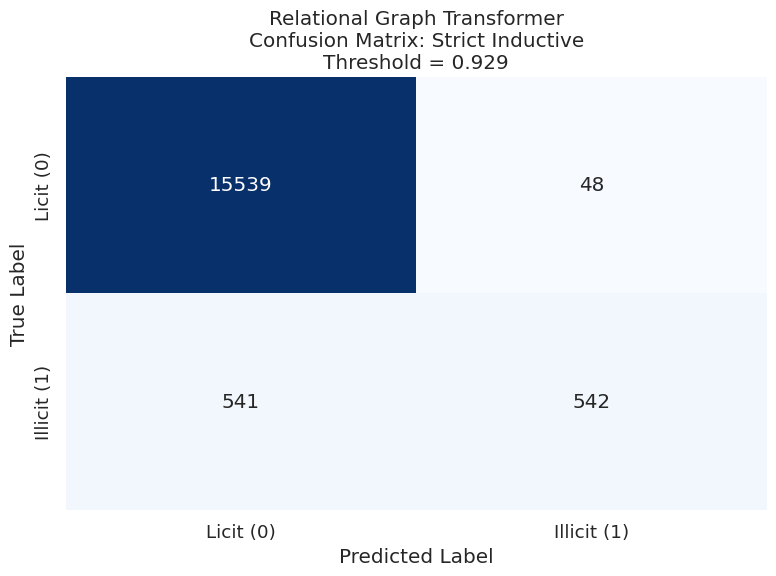

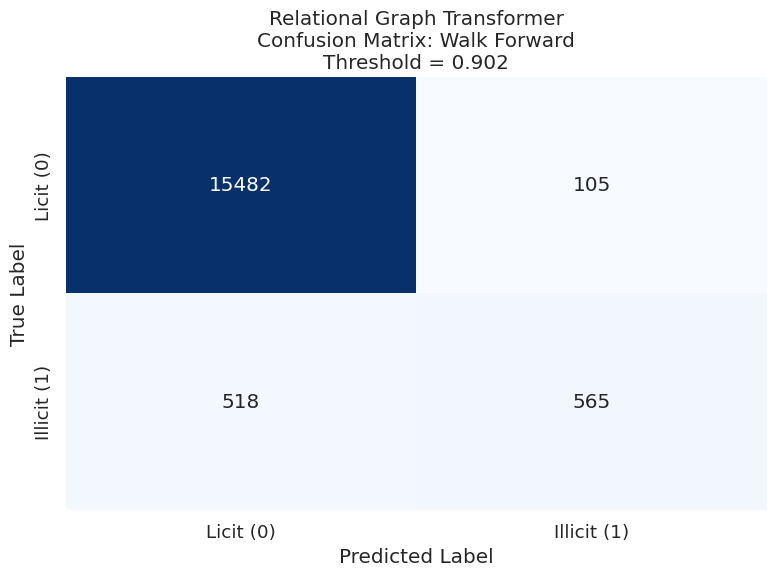

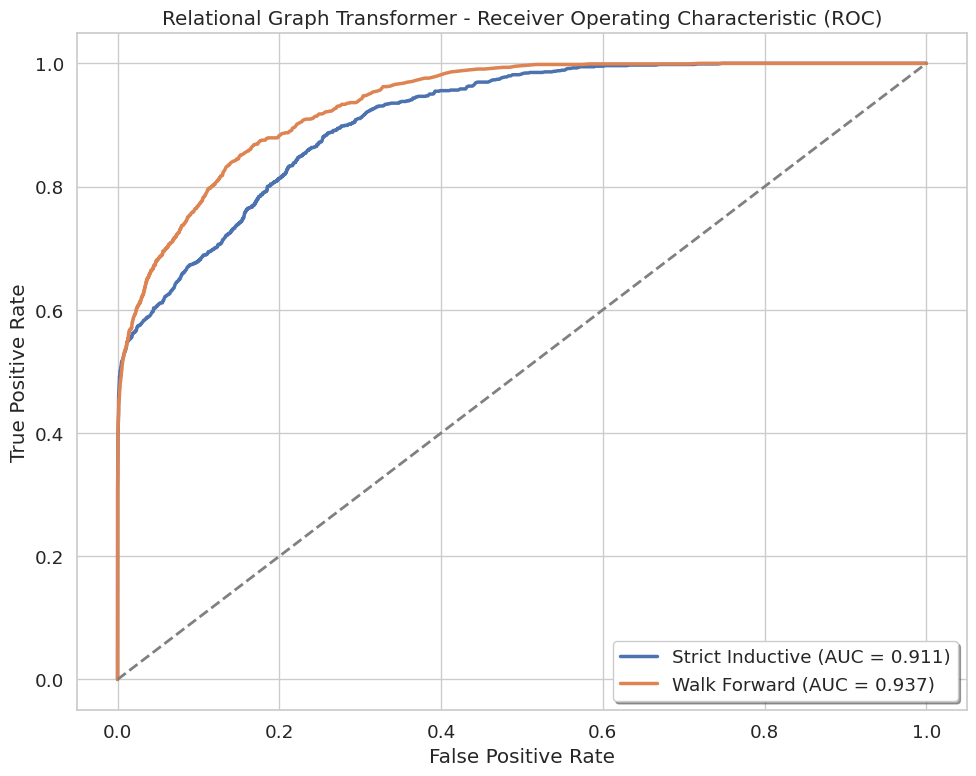

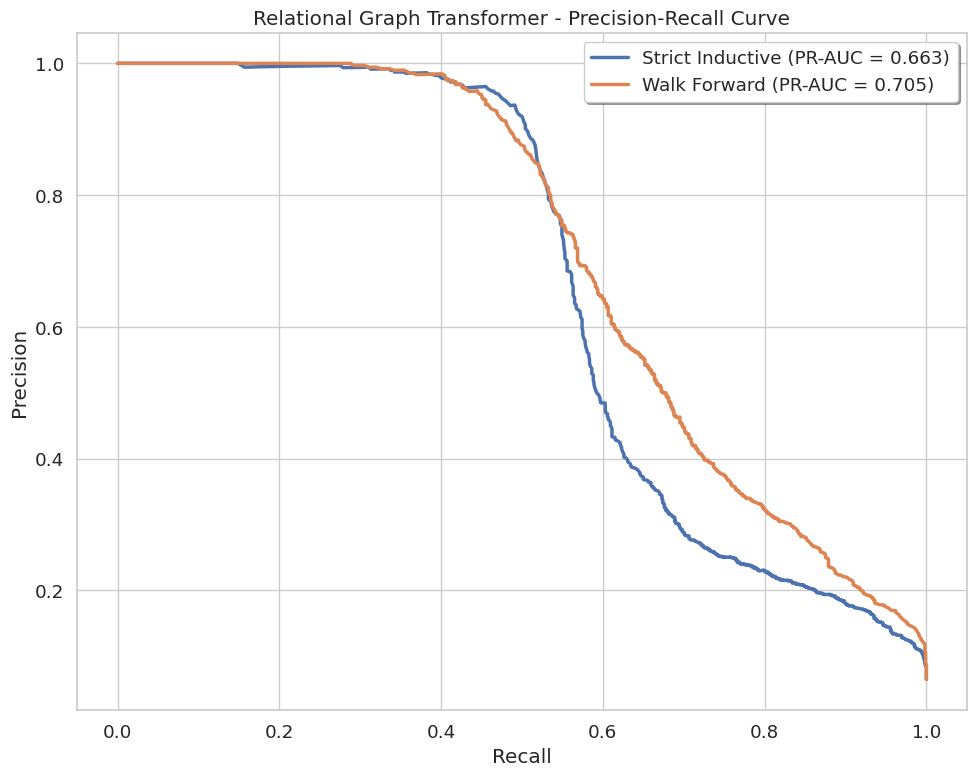

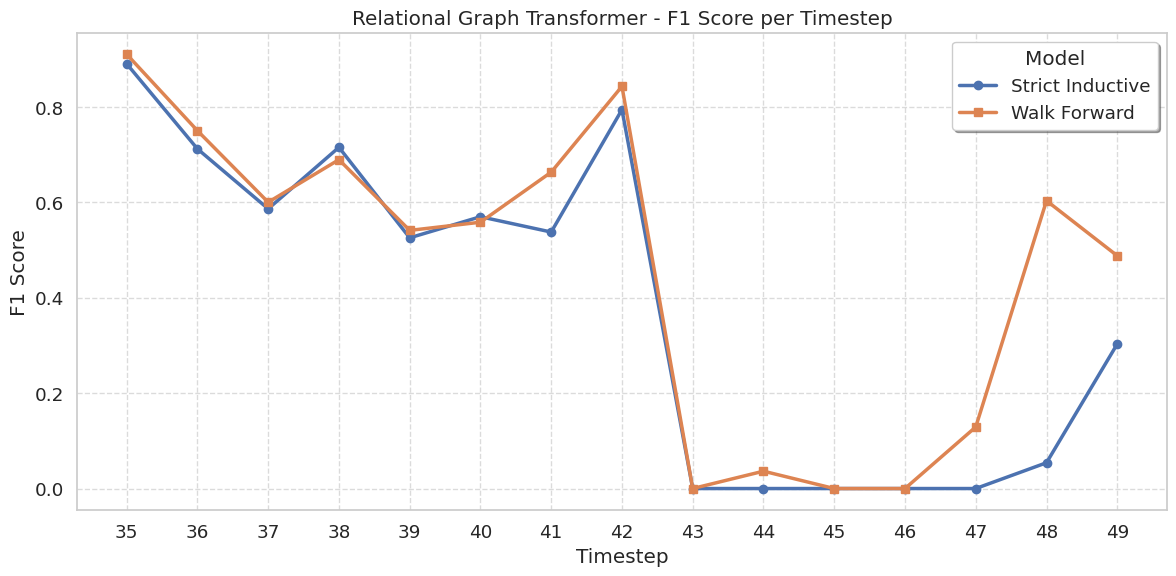

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, precision_recall_curve, f1_score

# Set industry-standard styling for paper-ready plots
sns.set_theme(style="whitegrid", font_scale=1.2)

# Data sources from the notebook
models = {
    'Strict Inductive': {
        'y_test': strict_res['y_test'],
        'p_test': strict_res['p_test'],
        'thr': strict_res['thr'],
        'auc': strict_res['auc'],
        'prauc': strict_res['prauc']
    },
    'Walk Forward': {
        'y_test': np.concatenate(walk_pooled_y) if walk_pooled_y else np.array([]),
        'p_test': np.concatenate(walk_pooled_p) if walk_pooled_p else np.array([]),
        'thr': walk_pooled['thr'],
        'auc': walk_pooled['auc'],
        'prauc': walk_pooled['prauc']
    }
}

# 1. Confusion Matrices
for name, data in models.items():
    if len(data['y_test']) == 0: continue
    y_true = data['y_test']
    y_pred = (data['p_test'] >= data['thr']).astype(int)

    plt.figure(figsize=(8, 6))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Licit (0)', 'Illicit (1)'],
                yticklabels=['Licit (0)', 'Illicit (1)'])
    plt.title(f"Relational Graph Transformer\nConfusion Matrix: {name}\nThreshold = {data['thr']:.3f}")
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.tight_layout()
    plt.show()

# 2. ROC Curve
plt.figure(figsize=(10, 8))
for name, data in models.items():
    if len(data['y_test']) == 0: continue
    fpr, tpr, _ = roc_curve(data['y_test'], data['p_test'])
    plt.plot(fpr, tpr, lw=2.5, label=f"{name} (AUC = {data['auc']:.3f})")

plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2)
plt.title('Relational Graph Transformer - Receiver Operating Characteristic (ROC)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right", frameon=True, shadow=True)
plt.tight_layout()
plt.show()

# 3. Precision-Recall Curve
plt.figure(figsize=(10, 8))
for name, data in models.items():
    if len(data['y_test']) == 0: continue
    prec, rec, _ = precision_recall_curve(data['y_test'], data['p_test'])
    plt.plot(rec, prec, lw=2.5, label=f"{name} (PR-AUC = {data['prauc']:.3f})")

plt.title('Relational Graph Transformer - Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.legend(loc="upper right", frameon=True, shadow=True)
plt.tight_layout()
plt.show()

# 4. F1 Score per Timestep
plt.figure(figsize=(12, 6))

# Strict Inductive per timestep F1
test_times_strict = []
for k in range(1, N_TIMESTEPS + 1):
    mask_k = m_test & (tx_t_arr == k)
    if mask_k.any():
        test_times_strict.extend([k] * mask_k.sum())
test_times_strict = np.array(test_times_strict)

timesteps_strict = sorted(list(set(test_times_strict)))
f1_scores_strict = []
for t in timesteps_strict:
    idx = (test_times_strict == t)
    if idx.sum() > 0:
        y_t = strict_res['y_test'][idx]
        p_t = strict_res['p_test'][idx]
        f1 = f1_score(y_t, (p_t >= strict_res['thr']).astype(int), pos_label=1, zero_division=0)
        f1_scores_strict.append(f1)
    else:
        f1_scores_strict.append(np.nan)

plt.plot(timesteps_strict, f1_scores_strict, marker='o', lw=2.5, label="Strict Inductive")

# Walk Forward per timestep F1 (from walk_per_T)
if walk_per_T:
    timesteps_walk = sorted(list(walk_per_T.keys()))
    f1_scores_walk = [walk_per_T[t]['f1'] for t in timesteps_walk]
    plt.plot(timesteps_walk, f1_scores_walk, marker='s', lw=2.5, label="Walk Forward")

plt.title('Relational Graph Transformer - F1 Score per Timestep')
plt.xlabel('Timestep')
plt.ylabel('F1 Score')
plt.xticks(TEST_TIMESTEPS)
plt.legend(title="Model", frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
